In [1]:
# --- [0단계] 한글 폰트 설치 (그래프 깨짐 방지) ---
# 이 셀을 실행한 후, 상단 메뉴 [런타임] -> [세션 다시 시작]을 꼭 해주세요!
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
# --- [1단계] 데이터 로드 및 전처리 ---
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
X_raw = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y_raw = raw_df.values[1::2, 2].reshape(-1, 1)

# 특성 이름 (범죄율, 방 개수, 교육 환경 등)
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# 데이터 표준화 (평균 0, 분산 1로 조정)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 데이터 분할 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_raw, test_size=0.2, random_state=42)

In [3]:
# --- [2단계] 정규화 모델(Ridge) 학습 ---
# alpha(규제 강도)를 통해 모델의 과적합을 방지합니다.
model_ridge = Ridge(alpha=10.0)
model_ridge.fit(X_train, y_train)

Ridge(alpha=10.0)

In [4]:
# --- [3단계] 개인화 추천 함수 정의 ---
def get_housing_recommendations(user_style, model, X_scaled, raw_data, top_n=5):
    # 모델이 학습한 기본 가중치(기여도)
    weights = model.coef_.flatten()
    intercept = model.intercept_

    # 사용자 취향 반영 (특정 특성 가중치 부스트)
    for feature, boost in user_style.items():
        if feature in feature_names:
            idx = feature_names.index(feature)
            weights[idx] *= boost  # 예: 교육 중시 시 해당 가중치 강화

    # 추천 점수 산출 (가중치와 데이터의 내적 합)
    scores = X_scaled.dot(weights) + intercept

    # 상위 N개 추천 리스트 추출
    top_indices = scores.argsort()[::-1][:top_n]

    # 결과 요약 데이터프레임
    recommendations = raw_data.iloc[top_indices].copy()
    recommendations['추천_점수'] = scores[top_indices]

    # 주요 지표만 출력 (방 개수, 교육 환경, 하위 계층 비율)
    return recommendations[['RM', 'PTRATIO', 'LSTAT', '추천_점수']]

In [7]:
# --- [4단계] 사용자 맞춤 추천 실행 ---
# 취향 설정: "나는 방이 많고(RM), 교육 여건(PTRATIO)이 좋은 곳을 선호해!"
my_style = {
    'RM': 1.8,      # 방 개수 중요도 80% 상향
    'PTRATIO': 2.5  # 교육 환경 중요도 150% 상향
}

# 결과 출력
print("🏠 03/21 개인화 주택 추천 시스템 실행 결과")
print("=" * 60)
final_list = get_housing_recommendations(my_style, model_ridge, X_scaled, pd.DataFrame(X_raw, columns=feature_names))
print(final_list)
print("=" * 60)

🏠 03/21 개인화 주택 추천 시스템 실행 결과
        RM  PTRATIO  LSTAT      추천_점수
257  8.704     13.0   5.12  59.689195
283  7.923     13.6   3.16  56.178745
262  8.398     13.0   5.91  56.133527
163  8.375     14.7   3.32  55.748742
267  8.297     13.0   7.44  55.595140


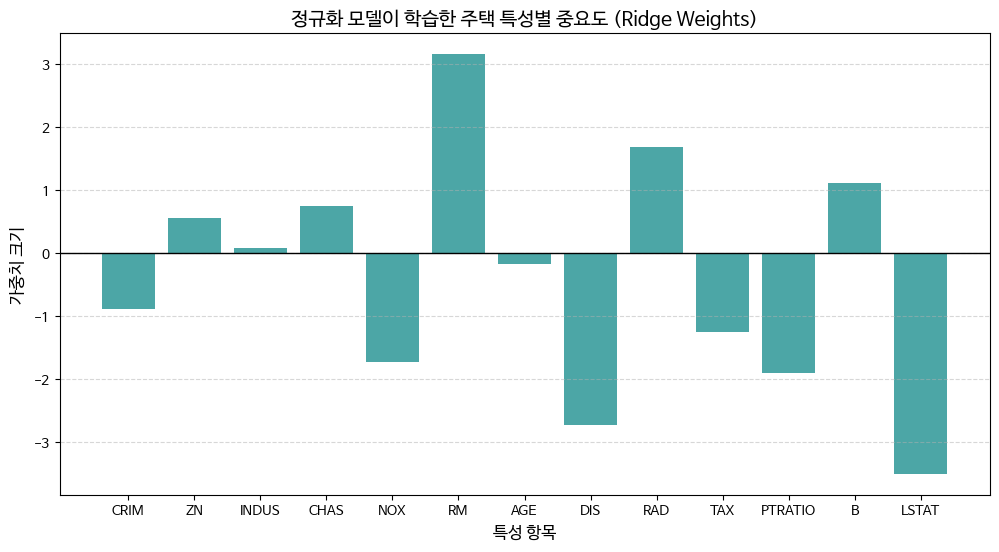

In [6]:
# --- [5단계] 특성 가중치 시각화 ---
plt.figure(figsize=(12, 6))
plt.bar(feature_names, model_ridge.coef_.flatten(), color='teal', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.title("정규화 모델이 학습한 주택 특성별 중요도 (Ridge Weights)", fontsize=14)
plt.xlabel("특성 항목", fontsize=12)
plt.ylabel("가중치 크기", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()